# BME 4810: Retinal OCT Classification — v3 Experimental Edition

**Authors**: Noah Benevides & Radi Elazazy

---

## Version History

| Version | Environment | Key Additions |
|:---:|:---|:---|
| **v1** | Google Colab (CPU) | Original course submission — baseline shallow ensembles + Keras CNNs |
| **v2** | Local GPU (CUDA) | Bug fixes, 66-D feature extractor, PyTorch CUDA acceleration (18× speedup), 0.962 AUC |
| **v3** | Local GPU (CUDA) — *this file* | Focal Loss, Cosine Annealing, Data Augmentation, ResNet CNN3, TTA, XGBoost GPU, Grad-CAM, SHAP |

---


## Section A: Project Objectives & Clinical Significance

Optical Coherence Tomography (OCT) is a non-invasive optical imaging modality that captures cross-sectional microstructural details of the retina at micron-scale resolution.
This v3 notebook extends the v2 pipeline with targeted architectural and data-level improvements aimed at surpassing the prior 73.0% test accuracy and 0.962 Macro ROC AUC baseline.

**Clinical targets:**
- **CNV** (Choroidal Neovascularization): Sub-retinal neovascular membrane with fluid exudation.
- **DME** (Diabetic Macular Edema): Intraretinal cystic edema from diabetic retinopathy.
- **DRUSEN**: Extracellular deposits beneath the RPE; AMD precursor.
- **NORMAL**: Intact foveal pit with stratified, continuous retinal layers.


## Section B: v3 Methods & Architectural Additions

### New Improvements in v3

| Improvement | Category | Expected Gain |
|:---|:---:|:---|
| **Focal Loss + Inverse-Frequency Class Weights** | Data/Training | High — forces focus on minority classes (DME, Drusen) |
| **Cosine Annealing with Warm Restarts** | Scheduler | High — periodic LR resets escape local minima |
| **Training-Time Data Augmentation** | Data | High — flip, rotation, jitter reduce overfitting |
| **Test-Time Augmentation (TTA, n=5)** | Inference | Medium — free 1–2% accuracy boost |
| **ResNet-Style CNN3** | Architecture | High — residual skip connections enable deeper representations |
| **XGBoost GPU (66 features)** | Pipeline 1 | Medium — GPU-accelerated gradient boosting on custom features |
| **Grad-CAM Heatmaps** | Explainability | Portfolio — visual proof of CNN attention regions |
| **SHAP Feature Importance** | Explainability | Portfolio — quantifies which retinal features drive XGBoost decisions |


In [1]:
import os, time, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns
from tqdm.auto import tqdm
warnings.filterwarnings('ignore')

# Scikit-learn
from sklearn.ensemble import RandomForestClassifier, VotingClassifier, StackingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, balanced_accuracy_score, precision_score,
                             recall_score, f1_score, roc_auc_score,
                             classification_report, confusion_matrix as compute_cm,
                             roc_curve, auc)
from sklearn.preprocessing import label_binarize

# XGBoost
import xgboost as xgb

# SHAP
import shap

# PyTorch
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, TensorDataset
import torchvision.transforms as T

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"PyTorch {torch.__version__} | Device: {device}")
if device == 'cuda':
    print(f"  GPU: {torch.cuda.get_device_name(0)}")
    print(f"  VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")


PyTorch 2.6.0+cu124 | Device: cuda
  GPU: NVIDIA GeForce GTX 1660 Ti
  VRAM: 6.4 GB


In [2]:
# ── Data Loading ──────────────────────────────────────────────────────────────
DATA_PATH = r'C:\Users\CTHUL\Desktop\school\Undergrad\5\Spring\UConn\BME machine learning\final project\Project_Packet\octmnist.npz'
data = np.load(DATA_PATH)

train_images = data['train_images']   # (97477, 28, 28)
train_labels = data['train_labels']   # (97477, 1)
val_images   = data['val_images']     # (10832, 28, 28)
val_labels   = data['val_labels']     # (10832, 1)
test_images  = data['test_images']    # (1000, 28, 28)
test_labels  = data['test_labels']    # (1000, 1)

CLASS_NAMES = ['CNV', 'DME', 'DRUSEN', 'NORMAL']

y_train = train_labels.flatten()
y_val   = val_labels.flatten()
y_test  = test_labels.flatten()

print(f"Train: {train_images.shape}  Val: {val_images.shape}  Test: {test_images.shape}")
print("Class distribution (train):", {c: int((y_train == i).sum()) for i, c in enumerate(CLASS_NAMES)})


Train: (97477, 28, 28)  Val: (10832, 28, 28)  Test: (1000, 28, 28)
Class distribution (train): {'CNV': 33484, 'DME': 10213, 'DRUSEN': 7754, 'NORMAL': 46026}


In [3]:
# ── Classical ML Preprocessing ─────────────────────────────────────────────
X_train_flat = train_images.reshape(len(train_images), -1).astype(np.float32) / 255.0
X_val_flat   = val_images.reshape(len(val_images), -1).astype(np.float32) / 255.0
X_test_flat  = test_images.reshape(len(test_images), -1).astype(np.float32) / 255.0
print(f"Flat pixels: train {X_train_flat.shape}, val {X_val_flat.shape}, test {X_test_flat.shape}")


Flat pixels: train (97477, 784), val (10832, 784), test (1000, 784)


In [4]:
# ── 66-D Biomedical Feature Extractor ─────────────────────────────────────
def extract_pixel_features(images):
    N = images.shape[0]
    imgs = images.astype(np.float32) / 255.0
    feats = np.zeros((N, 66), dtype=np.float32)
    h, w = 28, 28
    for i in range(N):
        img = imgs[i]
        idx = 0
        # 4x4 grid means (16)
        for r in range(4):
            for c in range(4):
                patch = img[r*7:(r+1)*7, c*7:(c+1)*7]
                feats[i, idx] = patch.mean(); idx += 1
        # 4x4 grid stds (16)
        for r in range(4):
            for c in range(4):
                patch = img[r*7:(r+1)*7, c*7:(c+1)*7]
                feats[i, idx] = patch.std(); idx += 1
        # Vertical depth profiles (14)
        for r in range(14):
            feats[i, idx] = img[r*2:(r+1)*2, :].mean(); idx += 1
        # Horizontal profiles (14)
        for c in range(14):
            feats[i, idx] = img[:, c*2:(c+1)*2].mean(); idx += 1
        # Global stats (6)
        feats[i, idx] = img.mean(); idx += 1
        feats[i, idx] = img.std(); idx += 1
        feats[i, idx] = img[11:17, 11:17].mean(); idx += 1
        feats[i, idx] = img[11:17, 11:17].std(); idx += 1
        feats[i, idx] = float(np.abs(np.diff(img, axis=1)).mean()); idx += 1
        feats[i, idx] = float(np.abs(np.diff(img, axis=0)).mean()); idx += 1
    return feats

FEATURE_NAMES = (
    [f'grid_mean_{r}_{c}' for r in range(4) for c in range(4)] +
    [f'grid_std_{r}_{c}'  for r in range(4) for c in range(4)] +
    [f'depth_row_{r}'     for r in range(14)] +
    [f'horiz_col_{c}'     for c in range(14)] +
    ['global_mean', 'global_std', 'foveal_mean', 'foveal_std', 'grad_h', 'grad_v']
)

print("Extracting features from all splits...")
t0 = time.time()
X_train_feat = extract_pixel_features(train_images)
X_val_feat   = extract_pixel_features(val_images)
X_test_feat  = extract_pixel_features(test_images)
print(f"Done in {time.time()-t0:.1f}s | Feature shape: {X_train_feat.shape}")


Extracting features from all splits...


Done in 112.2s | Feature shape: (97477, 66)


In [5]:
# ── Evaluation Harness ────────────────────────────────────────────────────
results_records = []

def evaluate_model(y_true, y_pred, y_prob, model_name, split_name='Test', plot=True):
    acc  = accuracy_score(y_true, y_pred)
    bacc = balanced_accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, average='macro', zero_division=0)
    rec  = recall_score(y_true, y_pred, average='macro', zero_division=0)
    f1m  = f1_score(y_true, y_pred, average='macro', zero_division=0)
    f1w  = f1_score(y_true, y_pred, average='weighted', zero_division=0)
    y_bin = label_binarize(y_true, classes=[0,1,2,3])
    try:
        roc = roc_auc_score(y_bin, y_prob, multi_class='ovr', average='macro')
    except:
        roc = float('nan')
    results_records.append({'Model': model_name, 'Split': split_name,
        'Accuracy': acc, 'Balanced Acc': bacc,
        'Precision (Macro)': prec, 'Recall (Macro)': rec,
        'F1 (Macro)': f1m, 'F1 (Weighted)': f1w, 'ROC AUC (Macro OvR)': roc})
    print(f"\n{'='*60}")
    print(f"  {model_name} | {split_name}")
    print(f"  Accuracy: {acc:.4f}  Balanced: {bacc:.4f}  AUC: {roc:.4f}")
    print(f"  Precision: {prec:.4f}  Recall: {rec:.4f}  F1: {f1m:.4f}")
    print(f"{'='*60}")
    if plot:
        fig, axes = plt.subplots(1, 2, figsize=(14, 5))
        cm_vals = compute_cm(y_true, y_pred)
        sns.heatmap(cm_vals, annot=True, fmt='d', cmap='Blues', ax=axes[0],
                    xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
        axes[0].set_title(f'{model_name} — Confusion Matrix ({split_name})')
        axes[0].set_xlabel('Predicted'); axes[0].set_ylabel('True')
        y_bin_plot = label_binarize(y_true, classes=[0,1,2,3])
        colors = ['#e74c3c','#3498db','#2ecc71','#f39c12']
        for i, (name, col) in enumerate(zip(CLASS_NAMES, colors)):
            fpr, tpr, _ = roc_curve(y_bin_plot[:,i], y_prob[:,i])
            axes[1].plot(fpr, tpr, color=col, lw=2, label=f'{name} (AUC={auc(fpr,tpr):.3f})')
        axes[1].plot([0,1],[0,1],'k--',lw=1)
        axes[1].set_xlabel('FPR'); axes[1].set_ylabel('TPR')
        axes[1].set_title(f'{model_name} — ROC Curves ({split_name})')
        axes[1].legend(loc='lower right')
        plt.suptitle(f'AUC macro={roc:.4f}  Acc={acc:.4f}', y=1.02)
        plt.tight_layout(); plt.show()
    return roc


---
## [NEW v3] Data Augmentation & Focal Loss Setup


In [6]:
# ── [ITEM 4] Augmented Dataset ────────────────────────────────────────────

class OCTDataset(Dataset):
    def __init__(self, images, labels, transform=None):
        # images: (N, 28, 28) uint8
        self.images = images
        self.labels = labels.flatten().astype(np.int64)
        self.transform = transform

    def __len__(self): return len(self.images)

    def __getitem__(self, idx):
        img = self.images[idx]  # (28, 28) uint8
        # Convert to (H, W, 1) for ToPILImage
        img_3ch = np.stack([img, img, img], axis=-1)  # (28,28,3)
        if self.transform:
            from PIL import Image
            pil = Image.fromarray(img_3ch, mode='RGB')
            tensor = self.transform(pil)          # (3,28,28)
            tensor = tensor.mean(dim=0, keepdim=True)  # collapse back to (1,28,28)
        else:
            tensor = torch.tensor(img / 255.0, dtype=torch.float32).unsqueeze(0)
        return tensor, self.labels[idx]

train_aug_transform = T.Compose([
    T.RandomHorizontalFlip(p=0.5),
    T.RandomRotation(degrees=7),
    T.ColorJitter(brightness=0.15, contrast=0.15),
    T.GaussianBlur(kernel_size=3, sigma=(0.1, 0.5)),
    T.ToTensor(),
])
val_transform = T.Compose([T.ToTensor()])

BATCH_SIZE = 256
train_dataset_aug = OCTDataset(train_images, train_labels, transform=train_aug_transform)
val_dataset       = OCTDataset(val_images,   val_labels,   transform=None)
test_dataset      = OCTDataset(test_images,  test_labels,  transform=None)

train_loader_aug = DataLoader(train_dataset_aug, batch_size=BATCH_SIZE, shuffle=True,  num_workers=0, pin_memory=True)
val_loader       = DataLoader(val_dataset,       batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=True)
test_loader      = DataLoader(test_dataset,      batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=True)

print(f"Augmented train loader: {len(train_loader_aug)} batches of {BATCH_SIZE}")
print(f"Val loader:  {len(val_loader)} batches | Test loader: {len(test_loader)} batches")


Augmented train loader: 381 batches of 256
Val loader:  43 batches | Test loader: 4 batches


In [7]:
# ── [ITEM 1] Focal Loss + Inverse-Frequency Class Weights ───────────────

# Compute inverse-frequency class weights from training distribution
class_counts = np.bincount(y_train, minlength=4).astype(np.float32)
N_total = len(y_train)
class_weights = N_total / (4.0 * class_counts)
class_weights_tensor = torch.tensor(class_weights, dtype=torch.float32).to(device)

print("Class counts:", dict(zip(CLASS_NAMES, class_counts.astype(int))))
print("Class weights:", dict(zip(CLASS_NAMES, np.round(class_weights, 3))))

class FocalLoss(nn.Module):
    """Focal Loss with per-class alpha weighting for class imbalance."""
    def __init__(self, alpha, gamma=2.0, reduction='mean'):
        super().__init__()
        self.alpha = alpha      # tensor of shape (num_classes,)
        self.gamma = gamma
        self.reduction = reduction

    def forward(self, logits, targets):
        # Weighted cross entropy gives log(p_t) terms
        ce_loss = F.cross_entropy(logits, targets, weight=self.alpha, reduction='none')
        pt = torch.exp(-ce_loss)
        focal_loss = (1 - pt) ** self.gamma * ce_loss
        if self.reduction == 'mean':
            return focal_loss.mean()
        return focal_loss.sum()

focal_criterion = FocalLoss(alpha=class_weights_tensor, gamma=2.0)
print(f"\nFocalLoss ready (gamma=2.0)")


Class counts:

 {'CNV': 33484, 'DME': 10213, 'DRUSEN': 7754, 'NORMAL': 46026}
Class weights: {'CNV': 0.728, 'DME': 2.386, 'DRUSEN': 3.143, 'NORMAL': 0.529}

FocalLoss ready (gamma=2.0)


---
## Pipeline 2 — v2 Baselines (kept for fair comparison)

These models use the same non-augmented loaders and CrossEntropyLoss as v2 to provide a fair reference point.


In [8]:
# Non-augmented loaders for v2 baseline models (fair comparison)
train_dataset_plain = OCTDataset(train_images, train_labels, transform=None)
train_loader_plain  = DataLoader(train_dataset_plain, batch_size=BATCH_SIZE,
                                  shuffle=True, num_workers=0, pin_memory=True)

plain_criterion = nn.CrossEntropyLoss()

def train_gpu_model(model, train_loader, val_loader, epochs=10, lr=1e-3,
                    model_title="Model", criterion=None, use_cosine=False):
    model = model.to(device)
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
    if criterion is None:
        criterion = nn.CrossEntropyLoss()

    if use_cosine:
        scheduler = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(
            optimizer, T_0=5, T_mult=1, eta_min=1e-6)
    else:
        scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
            optimizer, mode='max', factor=0.5, patience=3, verbose=False)

    history = {'train_loss':[], 'val_loss':[], 'train_acc':[], 'val_acc':[]}
    best_val_acc = 0.0
    best_state = None

    for epoch in range(1, epochs+1):
        # ── Train ──
        model.train()
        run_loss, run_correct, run_total = 0.0, 0, 0
        pbar = tqdm(train_loader, desc=f"[{model_title}] Ep {epoch}/{epochs}", leave=False)
        for xb, yb in pbar:
            xb, yb = xb.to(device), yb.to(device)
            optimizer.zero_grad()
            logits = model(xb)
            loss = criterion(logits, yb)
            loss.backward()
            optimizer.step()
            run_loss    += loss.item() * len(yb)
            run_correct += (logits.argmax(1) == yb).sum().item()
            run_total   += len(yb)
            pbar.set_postfix(loss=f"{loss.item():.3f}",
                             acc=f"{run_correct/run_total:.3f}")
        train_loss = run_loss / run_total
        train_acc  = run_correct / run_total

        # ── Validate ──
        model.eval()
        v_loss, v_correct, v_total = 0.0, 0, 0
        with torch.no_grad():
            for xb, yb in val_loader:
                xb, yb = xb.to(device), yb.to(device)
                logits = model(xb)
                v_loss    += criterion(logits, yb).item() * len(yb)
                v_correct += (logits.argmax(1) == yb).sum().item()
                v_total   += len(yb)
        val_loss = v_loss / v_total
        val_acc  = v_correct / v_total

        if use_cosine:
            scheduler.step(epoch)
        else:
            scheduler.step(val_acc)

        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['train_acc'].append(train_acc)
        history['val_acc'].append(val_acc)

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_state = {k: v.clone() for k, v in model.state_dict().items()}

        print(f"  Ep {epoch:02d}: train_loss={train_loss:.4f}  val_loss={val_loss:.4f}"
              f"  train_acc={train_acc:.4f}  val_acc={val_acc:.4f}")

    model.load_state_dict(best_state)
    print(f"\n  Best val acc: {best_val_acc:.4f}")
    return model, history

def plot_history(history, title):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))
    epochs = range(1, len(history['train_loss'])+1)
    ax1.plot(epochs, history['train_loss'], label='Train Loss', color='#e74c3c')
    ax1.plot(epochs, history['val_loss'],   label='Val Loss',   color='#3498db')
    ax1.set_title(f'{title} — Loss'); ax1.legend(); ax1.set_xlabel('Epoch')
    ax2.plot(epochs, history['train_acc'], label='Train Acc', color='#e74c3c')
    ax2.plot(epochs, history['val_acc'],   label='Val Acc',   color='#3498db')
    ax2.set_title(f'{title} — Accuracy'); ax2.legend(); ax2.set_xlabel('Epoch')
    plt.tight_layout(); plt.show()

def get_preds(model, loader):
    model.eval()
    all_preds, all_probs, all_labels = [], [], []
    with torch.no_grad():
        for xb, yb in loader:
            logits = model(xb.to(device))
            probs  = F.softmax(logits, dim=1).cpu().numpy()
            preds  = logits.argmax(1).cpu().numpy()
            all_probs.append(probs); all_preds.append(preds); all_labels.append(yb.numpy())
    return (np.concatenate(all_labels), np.concatenate(all_preds), np.concatenate(all_probs))

print("Training utilities ready.")


Training utilities ready.


---
## Pipeline 1: Classical ML Ensembles (v2 designs + new XGBoost)

Training Design 1A: Soft Voting Ensemble (HGB + RF + KNN)...


  Trained in 65.2s



  P1-Design 1A: Soft Voting Ensemble | Test
  Accuracy: 0.4770  Balanced: 0.4770  AUC: 0.8184
  Precision: 0.5828  Recall: 0.4770  F1: 0.3576


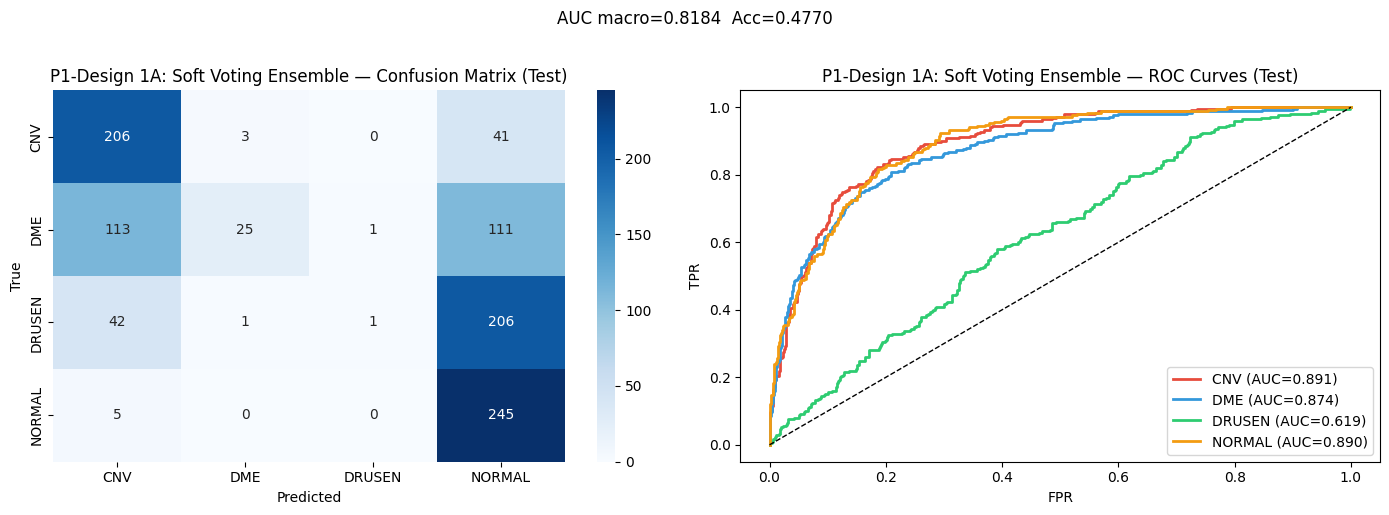

0.8183826666666667

In [9]:
# ── Design 1A: Soft Voting Ensemble ───────────────────────────────────────
print("Training Design 1A: Soft Voting Ensemble (HGB + RF + KNN)...")
# Use stratified subsample for KNN / RF speed
idx_sub, _ = train_test_split(np.arange(len(y_train)), train_size=10000,
                               stratify=y_train, random_state=42)
X_sub = X_train_flat[idx_sub]; y_sub = y_train[idx_sub]

hgb1a = HistGradientBoostingClassifier(max_iter=200, learning_rate=0.05,
                                        max_depth=5, random_state=42)
rf1a  = RandomForestClassifier(n_estimators=200, max_depth=12,
                                n_jobs=-1, random_state=42)
knn1a = KNeighborsClassifier(n_neighbors=7, n_jobs=-1)

t0 = time.time()
voter = VotingClassifier([('hgb', hgb1a), ('rf', rf1a), ('knn', knn1a)], voting='soft', n_jobs=-1)
voter.fit(X_sub, y_sub)
print(f"  Trained in {time.time()-t0:.1f}s")

y_pred_1a = voter.predict(X_test_flat)
y_prob_1a = voter.predict_proba(X_test_flat)
evaluate_model(y_test, y_pred_1a, y_prob_1a, 'P1-Design 1A: Soft Voting Ensemble')


Training Design 1B: PCA (90% var) + StackingClassifier...


  PCA components: 21 (90% var)



  P1-Design 1B: PCA + Stacking | Test
  Accuracy: 0.4520  Balanced: 0.4520  AUC: 0.7932
  Precision: 0.4244  Recall: 0.4520  F1: 0.3595


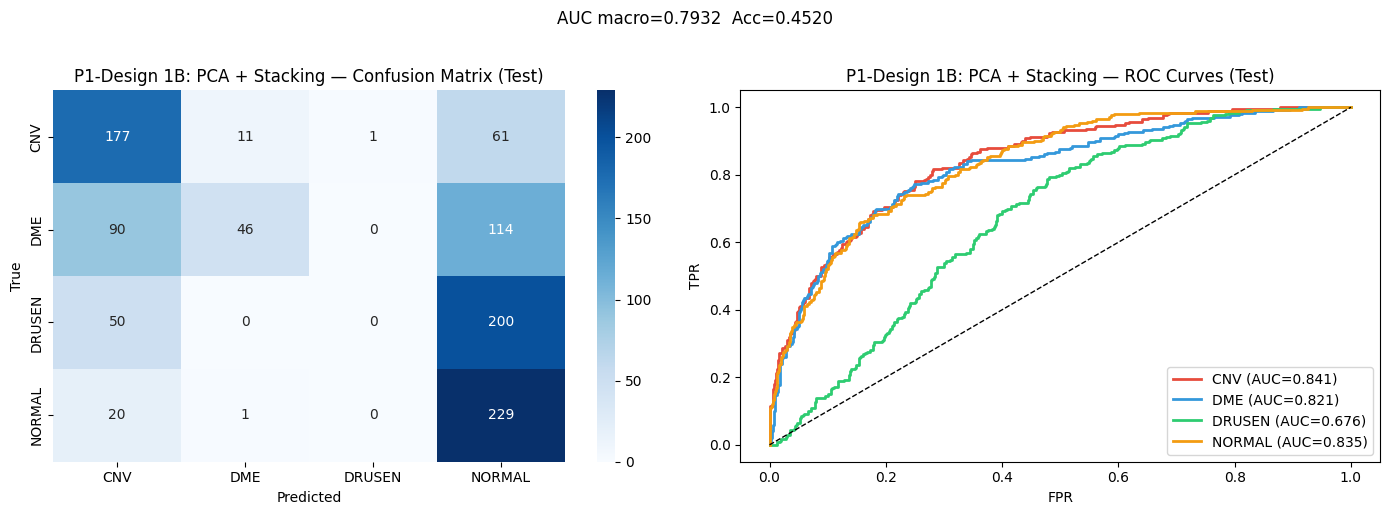

0.7932266666666667

In [10]:
# ── Design 1B: PCA (90% Variance) + Stacking ─────────────────────────────
print("Training Design 1B: PCA (90% var) + StackingClassifier...")
pca = PCA(n_components=0.90, random_state=42)
X_tr_pca  = pca.fit_transform(X_train_flat[:10000])
X_te_pca  = pca.transform(X_test_flat)
print(f"  PCA components: {pca.n_components_} (90% var)")

rf1b  = RandomForestClassifier(n_estimators=200, max_depth=12, n_jobs=-1, random_state=42)
hgb1b = HistGradientBoostingClassifier(max_iter=150, learning_rate=0.05, random_state=42)
meta  = LogisticRegression(max_iter=500, C=1.0)
stack = StackingClassifier(estimators=[('rf', rf1b), ('hgb', hgb1b)],
                            final_estimator=meta, cv=3, passthrough=False, n_jobs=-1)
stack.fit(X_tr_pca, y_train[:10000])

y_pred_1b = stack.predict(X_te_pca)
y_prob_1b = stack.predict_proba(X_te_pca)
evaluate_model(y_test, y_pred_1b, y_prob_1b, 'P1-Design 1B: PCA + Stacking')


Training Design 1C: HistGradientBoosting on 66 Custom Features...



  P1-Design 1C: HGB 66-Features | Test
  Accuracy: 0.5800  Balanced: 0.5800  AUC: 0.8755
  Precision: 0.6707  Recall: 0.5800  F1: 0.5020


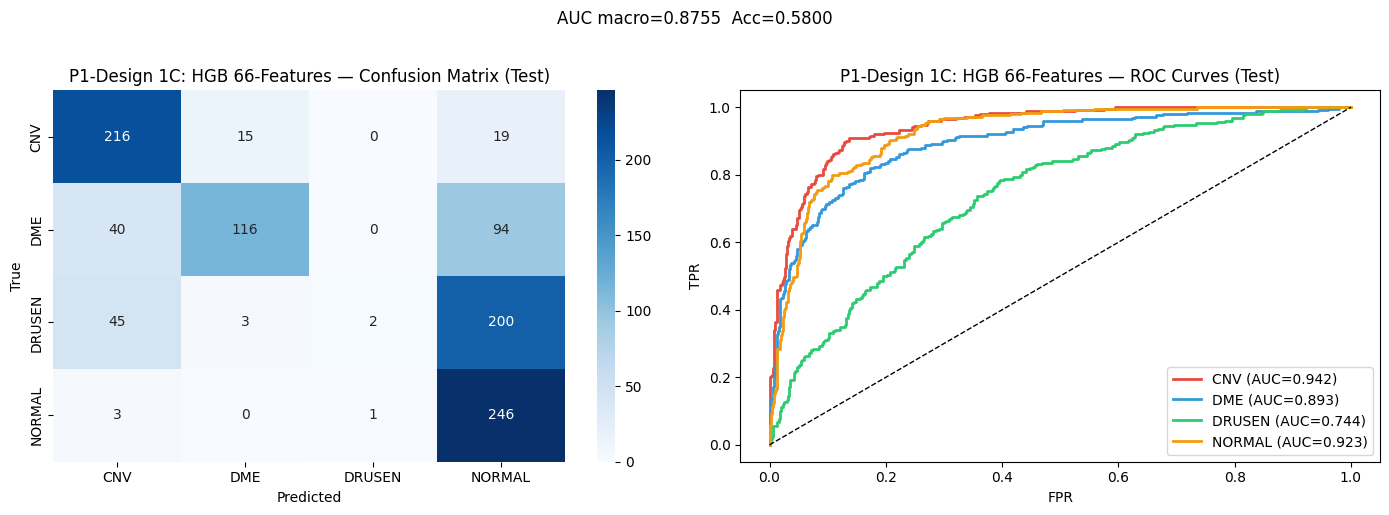

0.8755413333333333

In [11]:
# ── Design 1C: HGB on 66 Custom Features (for SHAP reference) ───────────
print("Training Design 1C: HistGradientBoosting on 66 Custom Features...")
hgb1c = HistGradientBoostingClassifier(max_iter=300, learning_rate=0.05,
                                         max_depth=5, random_state=42)
hgb1c.fit(X_train_feat, y_train)

y_pred_1c = hgb1c.predict(X_test_feat)
y_prob_1c = hgb1c.predict_proba(X_test_feat)
evaluate_model(y_test, y_pred_1c, y_prob_1c, 'P1-Design 1C: HGB 66-Features')


Training Design 1D: Optimized Full HGB on raw pixels (5k subsample)...



  P1-Design 1D: Optimized HGB Full Pixels | Test
  Accuracy: 0.4910  Balanced: 0.4910  AUC: 0.8159
  Precision: 0.5818  Recall: 0.4910  F1: 0.3765


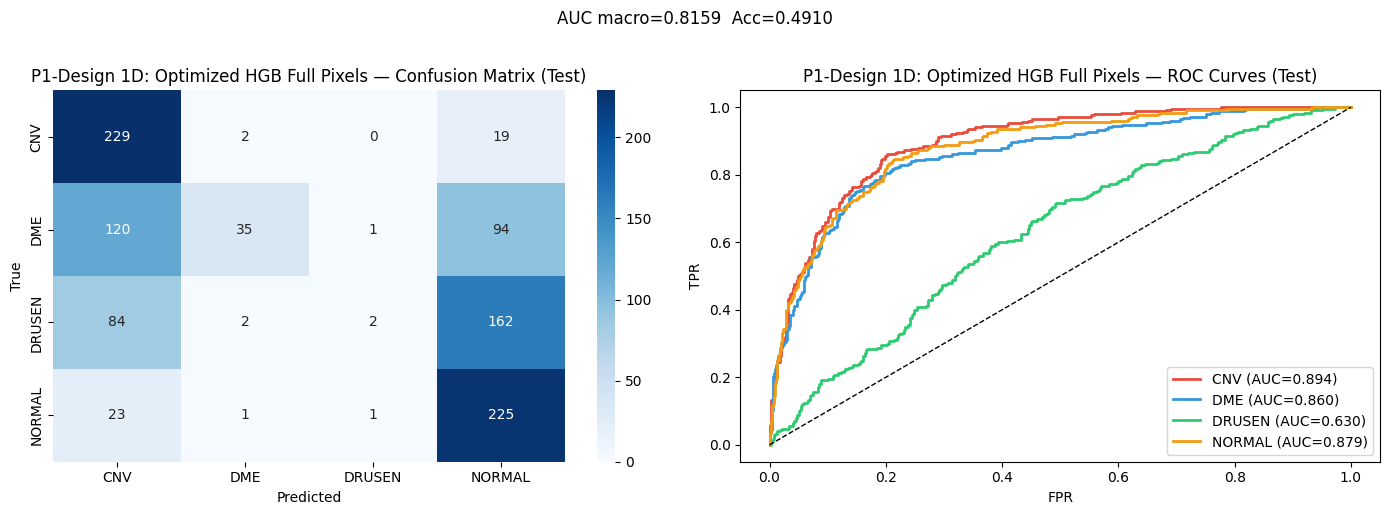

0.8159426666666667

In [12]:
# ── Design 1D: Optimized Full-Dataset HGB ────────────────────────────────
print("Training Design 1D: Optimized Full HGB on raw pixels (5k subsample)...")
idx5k, _ = train_test_split(np.arange(len(y_train)), train_size=5000,
                             stratify=y_train, random_state=42)
hgb1d = HistGradientBoostingClassifier(max_iter=300, learning_rate=0.03,
                                         max_depth=6, min_samples_leaf=20,
                                         l2_regularization=0.1, random_state=42)
hgb1d.fit(X_train_flat[idx5k], y_train[idx5k])

y_pred_1d = hgb1d.predict(X_test_flat)
y_prob_1d = hgb1d.predict_proba(X_test_flat)
evaluate_model(y_test, y_pred_1d, y_prob_1d, 'P1-Design 1D: Optimized HGB Full Pixels')


Training Design 1E: XGBoost (GPU) on 66 Custom Features...


[0]	validation_0-mlogloss:1.13954


[50]	validation_0-mlogloss:0.79673


[100]	validation_0-mlogloss:0.71639


[150]	validation_0-mlogloss:0.67310


...

[400]	validation_0-mlogloss:0.57299


[450]	validation_0-mlogloss:0.56238


[499]	validation_0-mlogloss:0.55274


  Trained in 11.7s  |  Best round: 499



  P1-Design 1E: XGBoost GPU (66 Features) | Test
  Accuracy: 0.5900  Balanced: 0.5900  AUC: 0.8834
  Precision: 0.7488  Recall: 0.5900  F1: 0.5115


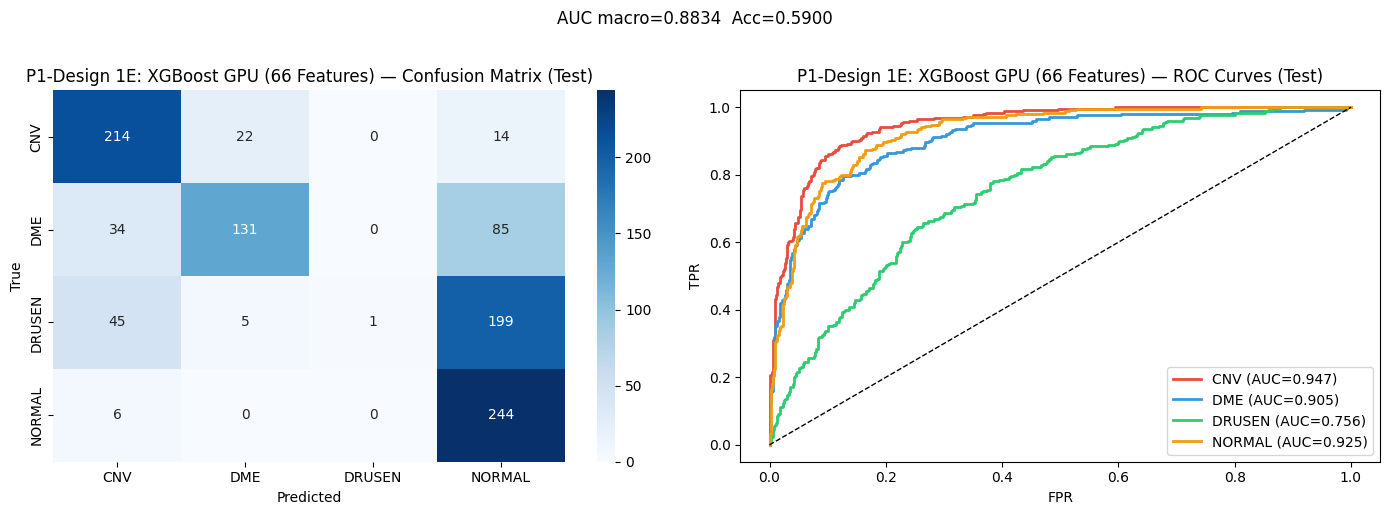

0.8833626666666665

In [13]:
# ── [NEW] Design 1E: XGBoost GPU on 66 Custom Features ──────────────────
print("Training Design 1E: XGBoost (GPU) on 66 Custom Features...")

xgb_device = 'cuda' if torch.cuda.is_available() else 'cpu'

xgb_model = xgb.XGBClassifier(
    n_estimators=500,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=3,
    gamma=0.1,
    reg_alpha=0.05,
    reg_lambda=1.0,
    tree_method='hist',
    device=xgb_device,
    objective='multi:softprob',
    num_class=4,
    eval_metric='mlogloss',
    early_stopping_rounds=30,
    verbosity=1,
    random_state=42,
    n_jobs=-1
)

t0 = time.time()
xgb_model.fit(
    X_train_feat, y_train,
    eval_set=[(X_val_feat, y_val)],
    verbose=50
)
print(f"  Trained in {time.time()-t0:.1f}s  |  Best round: {xgb_model.best_iteration}")

y_pred_1e = xgb_model.predict(X_test_feat)
y_prob_1e = xgb_model.predict_proba(X_test_feat)
evaluate_model(y_test, y_pred_1e, y_prob_1e, 'P1-Design 1E: XGBoost GPU (66 Features)')


---
## Pipeline 2: Deep Neural Networks

### v2 Baseline Models (unchanged, for comparison)


[Design 2A: Deep MLP] Ep 1/10:   0%|          | 0/191 [00:00<?, ?it/s]

  Ep 01: train_loss=1.0137  val_loss=0.8378  train_acc=0.6015  val_acc=0.6823


[Design 2A: Deep MLP] Ep 2/10:   0%|          | 0/191 [00:00<?, ?it/s]

  Ep 02: train_loss=0.8267  val_loss=0.7808  train_acc=0.6949  val_acc=0.7090


[Design 2A: Deep MLP] Ep 3/10:   0%|          | 0/191 [00:00<?, ?it/s]

...

  Ep 08: train_loss=0.6375  val_loss=0.6185  train_acc=0.7714  val_acc=0.7758


[Design 2A: Deep MLP] Ep 9/10:   0%|          | 0/191 [00:00<?, ?it/s]

  Ep 09: train_loss=0.6258  val_loss=0.5906  train_acc=0.7761  val_acc=0.7893


[Design 2A: Deep MLP] Ep 10/10:   0%|          | 0/191 [00:00<?, ?it/s]

  Ep 10: train_loss=0.6150  val_loss=0.5691  train_acc=0.7805  val_acc=0.7967

  Best val acc: 0.7967


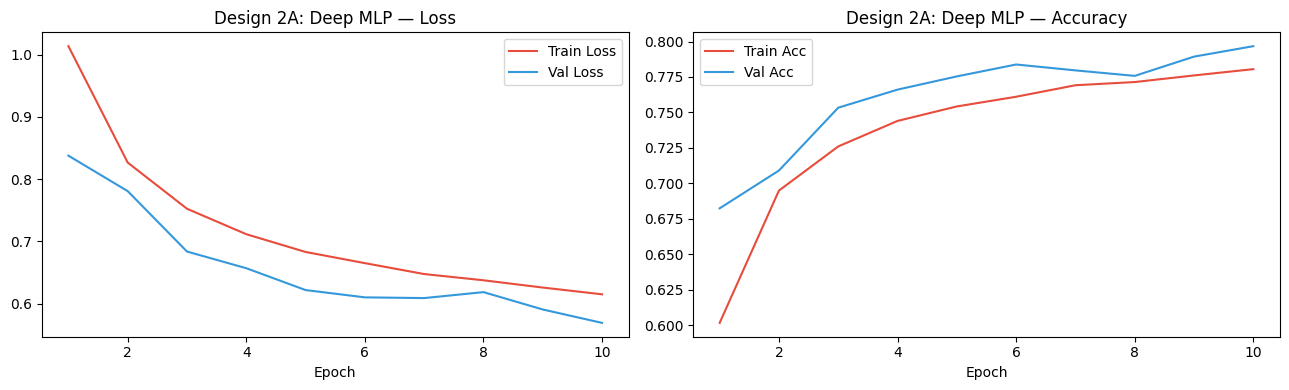


  P2-Design 2A: Deep MLP (66 Features) | Test
  Accuracy: 0.5870  Balanced: 0.5870  AUC: 0.8924
  Precision: 0.6659  Recall: 0.5870  F1: 0.5087


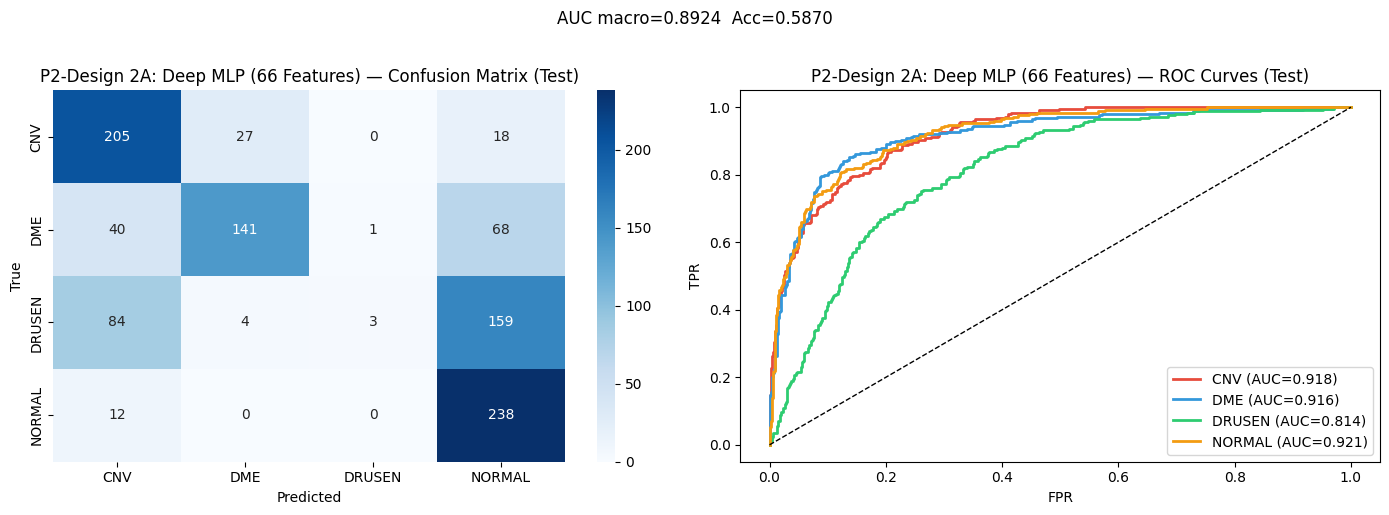

0.8924373333333333

In [14]:
# ── Design 2A: Deep MLP (v2 baseline) ────────────────────────────────────
class DeepMLP(nn.Module):
    def __init__(self, in_dim=66, num_classes=4):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, 256), nn.BatchNorm1d(256), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(256, 128),    nn.BatchNorm1d(128), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(128, 64),     nn.BatchNorm1d(64),  nn.ReLU(), nn.Dropout(0.2),
            nn.Linear(64, num_classes)
        )
    def forward(self, x): return self.net(x)

# Use feature tensors for MLP
train_feat_ds = TensorDataset(torch.tensor(X_train_feat), torch.tensor(y_train))
val_feat_ds   = TensorDataset(torch.tensor(X_val_feat),   torch.tensor(y_val))
test_feat_ds  = TensorDataset(torch.tensor(X_test_feat),  torch.tensor(y_test))
feat_train_loader = DataLoader(train_feat_ds, batch_size=512, shuffle=True)
feat_val_loader   = DataLoader(val_feat_ds,   batch_size=512, shuffle=False)
feat_test_loader  = DataLoader(test_feat_ds,  batch_size=512, shuffle=False)

mlp_model, mlp_hist = train_gpu_model(DeepMLP(), feat_train_loader, feat_val_loader,
                                        epochs=10, lr=1e-3, model_title="Design 2A: Deep MLP")
plot_history(mlp_hist, "Design 2A: Deep MLP")
yl_2a, yp_2a, yprob_2a = get_preds(mlp_model, feat_test_loader)
evaluate_model(yl_2a, yp_2a, yprob_2a, 'P2-Design 2A: Deep MLP (66 Features)')


[Design 2B: CNN1] Ep 1/10:   0%|          | 0/381 [00:00<?, ?it/s]

  Ep 01: train_loss=1.1488  val_loss=0.9576  train_acc=0.4964  val_acc=0.6384


[Design 2B: CNN1] Ep 2/10:   0%|          | 0/381 [00:00<?, ?it/s]

  Ep 02: train_loss=0.8846  val_loss=0.7476  train_acc=0.6914  val_acc=0.7399


[Design 2B: CNN1] Ep 3/10:   0%|          | 0/381 [00:00<?, ?it/s]

...

  Ep 08: train_loss=0.5448  val_loss=0.4640  train_acc=0.8167  val_acc=0.8389


[Design 2B: CNN1] Ep 9/10:   0%|          | 0/381 [00:00<?, ?it/s]

  Ep 09: train_loss=0.5255  val_loss=0.4373  train_acc=0.8245  val_acc=0.8500


[Design 2B: CNN1] Ep 10/10:   0%|          | 0/381 [00:00<?, ?it/s]

  Ep 10: train_loss=0.5073  val_loss=0.4224  train_acc=0.8298  val_acc=0.8532

  Best val acc: 0.8532


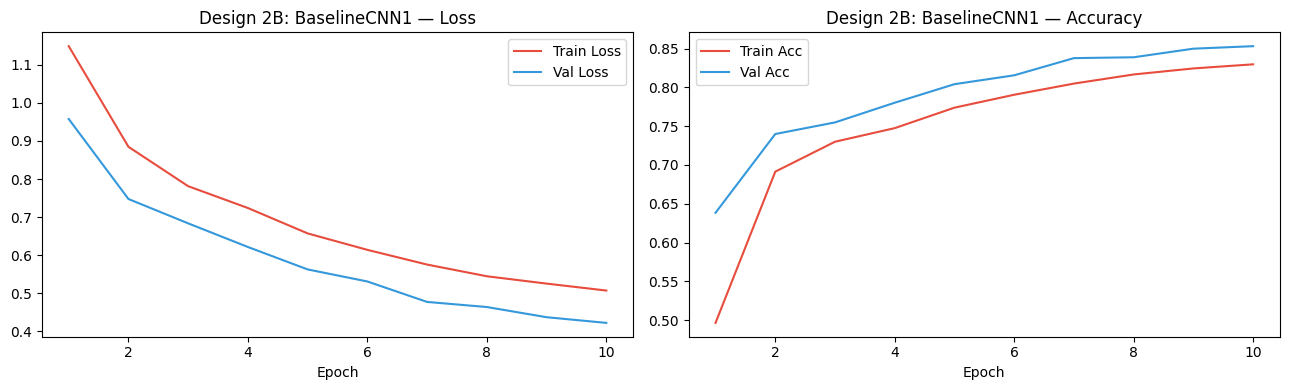


  P2-Design 2B: Baseline CNN1 | Test
  Accuracy: 0.6650  Balanced: 0.6650  AUC: 0.9374
  Precision: 0.5305  Recall: 0.6650  F1: 0.5756


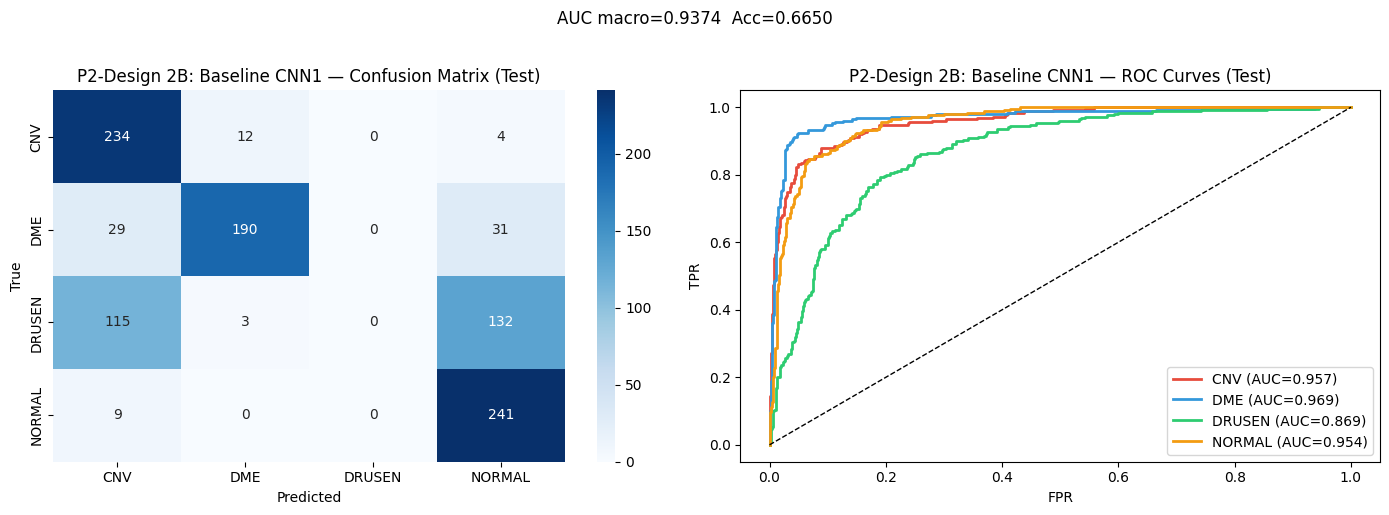

0.9373999999999999

In [15]:
# ── Design 2B: Baseline CNN1 (v2 baseline) ───────────────────────────────
class BaselineCNN1(nn.Module):
    def __init__(self, num_classes=4):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 32, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2), nn.Dropout2d(0.25),
            nn.Conv2d(32, 64, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2), nn.Dropout2d(0.25),
            nn.Conv2d(64, 128, 3, padding=1), nn.ReLU(),
        )
        self.classifier = nn.Sequential(
            nn.AdaptiveAvgPool2d(1), nn.Flatten(),
            nn.Linear(128, 64), nn.ReLU(), nn.Dropout(0.4),
            nn.Linear(64, num_classes)
        )
    def forward(self, x): return self.classifier(self.features(x))

cnn1_model, cnn1_hist = train_gpu_model(BaselineCNN1(), train_loader_plain, val_loader,
                                          epochs=10, lr=1e-3, model_title="Design 2B: CNN1",
                                          criterion=plain_criterion)
plot_history(cnn1_hist, "Design 2B: BaselineCNN1")
yl_2b, yp_2b, yprob_2b = get_preds(cnn1_model, test_loader)
evaluate_model(yl_2b, yp_2b, yprob_2b, 'P2-Design 2B: Baseline CNN1')


[Design 2C: CNN2] Ep 1/10:   0%|          | 0/381 [00:00<?, ?it/s]

  Ep 01: train_loss=0.6253  val_loss=0.4170  train_acc=0.7844  val_acc=0.8571


[Design 2C: CNN2] Ep 2/10:   0%|          | 0/381 [00:00<?, ?it/s]

  Ep 02: train_loss=0.4177  val_loss=0.3358  train_acc=0.8605  val_acc=0.8865


[Design 2C: CNN2] Ep 3/10:   0%|          | 0/381 [00:00<?, ?it/s]

...

  Ep 08: train_loss=0.2751  val_loss=0.2596  train_acc=0.9074  val_acc=0.9117


[Design 2C: CNN2] Ep 9/10:   0%|          | 0/381 [00:00<?, ?it/s]

  Ep 09: train_loss=0.2654  val_loss=0.2718  train_acc=0.9101  val_acc=0.9083


[Design 2C: CNN2] Ep 10/10:   0%|          | 0/381 [00:00<?, ?it/s]

  Ep 10: train_loss=0.2594  val_loss=0.2586  train_acc=0.9124  val_acc=0.9122

  Best val acc: 0.9135


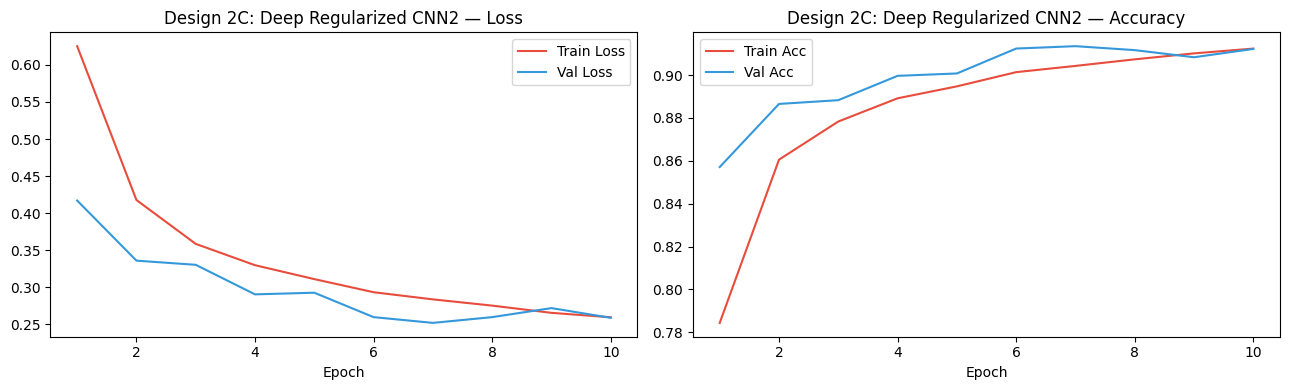


  P2-Design 2C: Deep Regularized CNN2 (v2) | Test
  Accuracy: 0.7590  Balanced: 0.7590  AUC: 0.9696
  Precision: 0.8221  Recall: 0.7590  F1: 0.7389


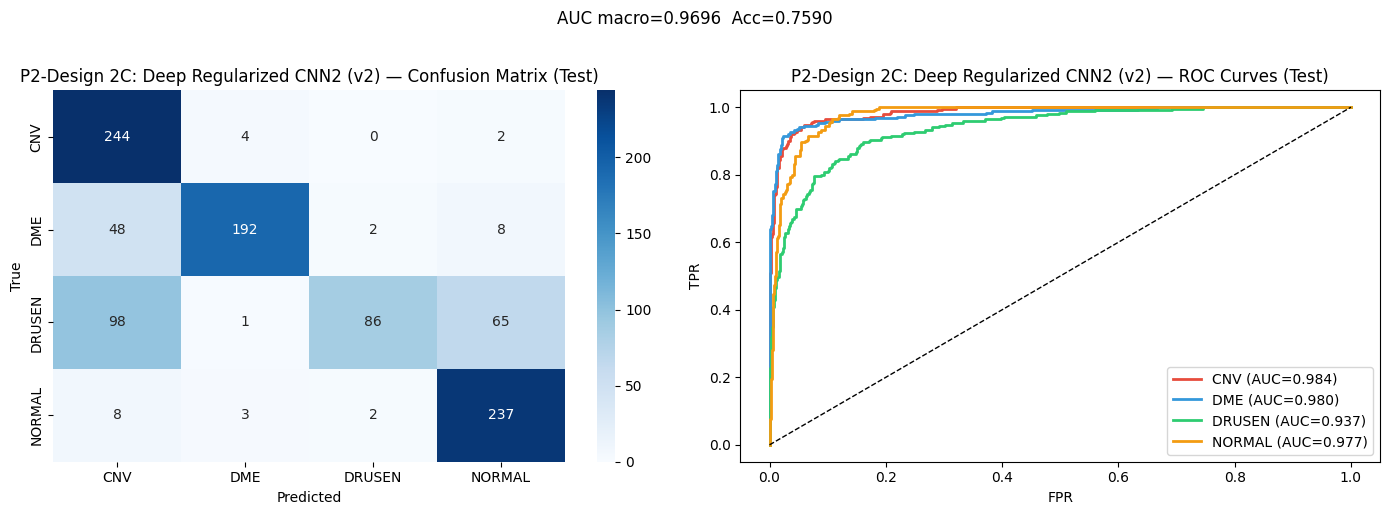

0.9696279999999999

In [16]:
# ── Design 2C: Deep Regularized CNN2 (v2 baseline) ───────────────────────
class DeepRegularizedCNN2(nn.Module):
    def __init__(self, num_classes=4):
        super().__init__()
        self.block1 = nn.Sequential(
            nn.Conv2d(1,  32, 3, padding=1), nn.BatchNorm2d(32),  nn.ReLU(),
            nn.Conv2d(32, 32, 3, padding=1), nn.BatchNorm2d(32),  nn.ReLU(),
            nn.MaxPool2d(2), nn.Dropout2d(0.25))
        self.block2 = nn.Sequential(
            nn.Conv2d(32, 64, 3, padding=1), nn.BatchNorm2d(64),  nn.ReLU(),
            nn.Conv2d(64, 64, 3, padding=1), nn.BatchNorm2d(64),  nn.ReLU(),
            nn.MaxPool2d(2), nn.Dropout2d(0.25))
        self.block3 = nn.Sequential(
            nn.Conv2d(64, 128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(),
            nn.Conv2d(128,128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU())
        self.head = nn.Sequential(
            nn.AdaptiveAvgPool2d(1), nn.Flatten(),
            nn.Linear(128, 64), nn.BatchNorm1d(64), nn.ReLU(), nn.Dropout(0.4),
            nn.Linear(64, num_classes))
    def forward(self, x):
        return self.head(self.block3(self.block2(self.block1(x))))

cnn2_model, cnn2_hist = train_gpu_model(DeepRegularizedCNN2(), train_loader_plain, val_loader,
                                          epochs=10, lr=1e-3, model_title="Design 2C: CNN2",
                                          criterion=plain_criterion)
plot_history(cnn2_hist, "Design 2C: Deep Regularized CNN2")
yl_2c, yp_2c, yprob_2c = get_preds(cnn2_model, test_loader)
evaluate_model(yl_2c, yp_2c, yprob_2c, 'P2-Design 2C: Deep Regularized CNN2 (v2)')


---
## [NEW v3] Pipeline 2 — Design 2D: ResidualCNN3

**New in v3**: Residual skip connections + Focal Loss + Cosine Annealing + Augmented training data.


In [17]:
# ── [ITEMS 1+2+4+5] Design 2D: ResidualCNN3 ─────────────────────────────

class ResidualBlock(nn.Module):
    """Basic residual block: two conv layers with identity skip connection."""
    def __init__(self, channels, dropout=0.25):
        super().__init__()
        self.conv1 = nn.Conv2d(channels, channels, 3, padding=1, bias=False)
        self.bn1   = nn.BatchNorm2d(channels)
        self.conv2 = nn.Conv2d(channels, channels, 3, padding=1, bias=False)
        self.bn2   = nn.BatchNorm2d(channels)
        self.drop  = nn.Dropout2d(dropout)

    def forward(self, x):
        residual = x
        out = F.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        out = out + residual    # identity skip connection
        return F.relu(self.drop(out))


class ResidualCNN3(nn.Module):
    """ResNet-inspired CNN3 with 3 residual stages and global average pooling."""
    def __init__(self, num_classes=4):
        super().__init__()
        # Stem
        self.stem = nn.Sequential(
            nn.Conv2d(1, 32, 3, padding=1, bias=False),
            nn.BatchNorm2d(32), nn.ReLU()
        )
        # Stage 1: 32 channels, residual block + pool
        self.stage1 = nn.Sequential(
            ResidualBlock(32, dropout=0.20),
            nn.MaxPool2d(2)          # 28→14
        )
        # Transition 1→2
        self.trans12 = nn.Sequential(
            nn.Conv2d(32, 64, 1, bias=False), nn.BatchNorm2d(64), nn.ReLU()
        )
        # Stage 2: 64 channels, residual block + pool
        self.stage2 = nn.Sequential(
            ResidualBlock(64, dropout=0.25),
            nn.MaxPool2d(2)          # 14→7
        )
        # Transition 2→3
        self.trans23 = nn.Sequential(
            nn.Conv2d(64, 128, 1, bias=False), nn.BatchNorm2d(128), nn.ReLU()
        )
        # Stage 3: 128 channels, residual block (no pool — 7×7 is small)
        self.stage3 = ResidualBlock(128, dropout=0.25)

        # Classification head
        self.head = nn.Sequential(
            nn.AdaptiveAvgPool2d(1), nn.Flatten(),
            nn.Linear(128, 64), nn.BatchNorm1d(64), nn.ReLU(), nn.Dropout(0.4),
            nn.Linear(64, num_classes)
        )

    def forward(self, x):
        x = self.stem(x)
        x = self.stage1(x)
        x = self.trans12(x)
        x = self.stage2(x)
        x = self.trans23(x)
        x = self.stage3(x)
        return self.head(x)

    def get_cam_layer(self):
        """Returns the last convolutional layer for Grad-CAM hooks."""
        return self.stage3.conv2

cnn3 = ResidualCNN3().to(device)
total_params = sum(p.numel() for p in cnn3.parameters() if p.requires_grad)
print(f"ResidualCNN3 — trainable parameters: {total_params:,}")
print(cnn3)


ResidualCNN3 — trainable parameters: 407,588
ResidualCNN3(
  (stem): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
  )
  (stage1): Sequential(
    (0): ResidualBlock(
      (conv1): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (drop): Dropout2d(p=0.2, inplace=False)
    )
    (1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (trans12): Sequential(
    (0): Conv2d(32, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track

[Design 2D: ResidualCNN3 (v3)] Ep 1/15:   0%|          | 0/381 [00:00<?, ?it/s]

  Ep 01: train_loss=0.6062  val_loss=0.3944  train_acc=0.3607  val_acc=0.4561


[Design 2D: ResidualCNN3 (v3)] Ep 2/15:   0%|          | 0/381 [00:00<?, ?it/s]

  Ep 02: train_loss=0.4000  val_loss=0.2954  train_acc=0.4844  val_acc=0.5513


[Design 2D: ResidualCNN3 (v3)] Ep 3/15:   0%|          | 0/381 [00:00<?, ?it/s]

...

  Ep 13: train_loss=0.2448  val_loss=0.1944  train_acc=0.6180  val_acc=0.6657


[Design 2D: ResidualCNN3 (v3)] Ep 14/15:   0%|          | 0/381 [00:00<?, ?it/s]

  Ep 14: train_loss=0.2293  val_loss=0.1922  train_acc=0.6371  val_acc=0.7508


[Design 2D: ResidualCNN3 (v3)] Ep 15/15:   0%|          | 0/381 [00:00<?, ?it/s]

  Ep 15: train_loss=0.2196  val_loss=0.1852  train_acc=0.6439  val_acc=0.6977

  Best val acc: 0.7508


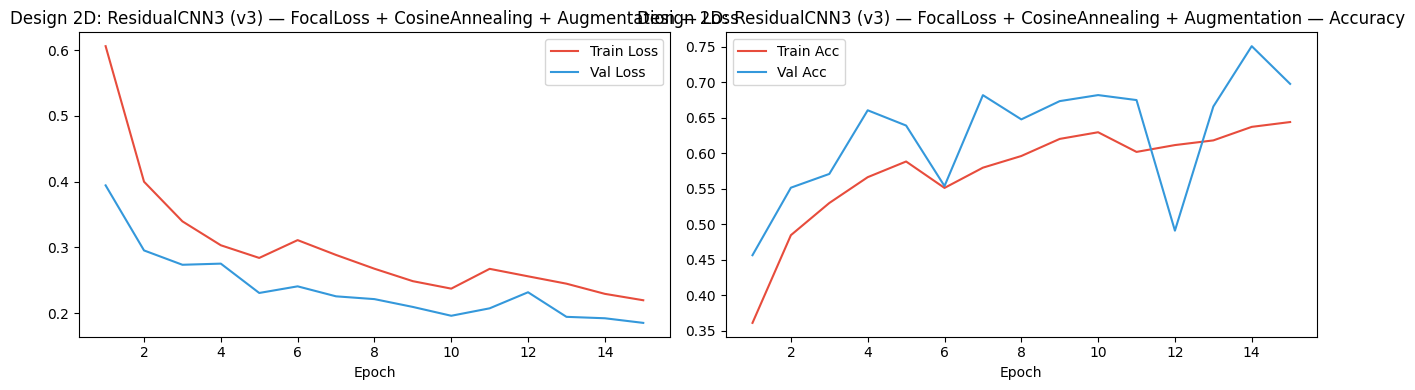


  P2-Design 2D: ResidualCNN3 (v3, no TTA) | Test
  Accuracy: 0.7490  Balanced: 0.7490  AUC: 0.9585
  Precision: 0.7871  Recall: 0.7490  F1: 0.7446


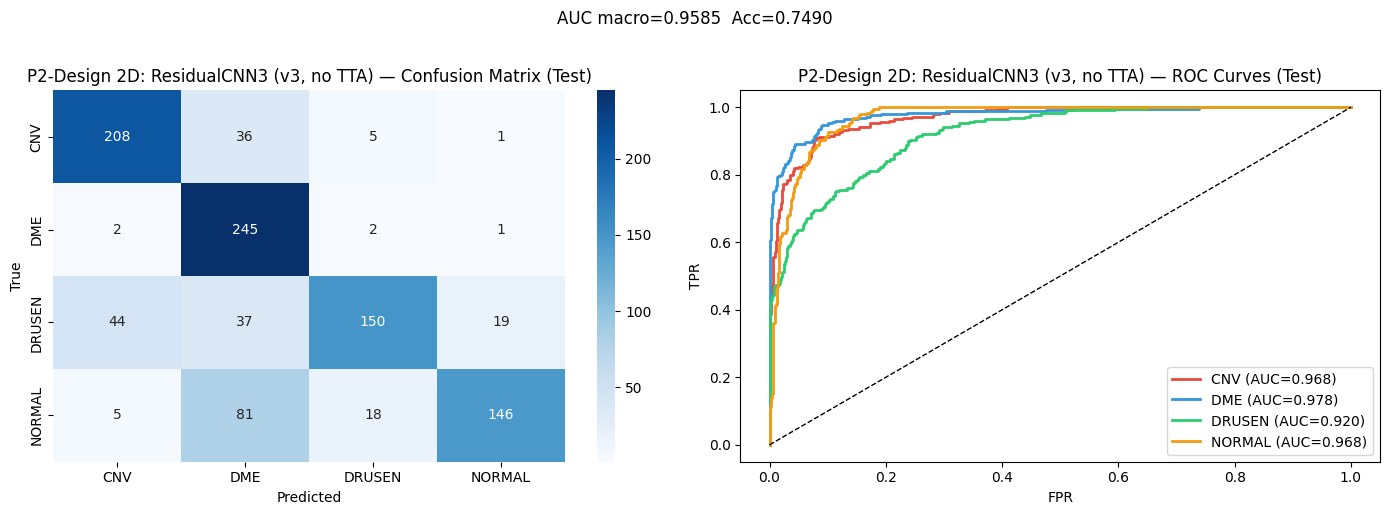

0.9585266666666666

In [18]:
# ── Train CNN3 with FocalLoss + CosineAnnealing + Augmented Loader ────────

cnn3_model, cnn3_hist = train_gpu_model(
    ResidualCNN3(),
    train_loader_aug,       # [ITEM 4] augmented training loader
    val_loader,
    epochs=15,
    lr=1e-3,
    model_title="Design 2D: ResidualCNN3 (v3)",
    criterion=focal_criterion,   # [ITEM 1] Focal Loss
    use_cosine=True              # [ITEM 2] CosineAnnealingWarmRestarts
)

plot_history(cnn3_hist, "Design 2D: ResidualCNN3 (v3) — FocalLoss + CosineAnnealing + Augmentation")

yl_2d, yp_2d, yprob_2d = get_preds(cnn3_model, test_loader)
evaluate_model(yl_2d, yp_2d, yprob_2d, 'P2-Design 2D: ResidualCNN3 (v3, no TTA)')


---
## [NEW v3] Test-Time Augmentation (TTA)

Run each test image through CNN3 multiple times with random augmentations and average the predicted probability vectors.


Running TTA inference (n=5 augmented passes)...


TTA inference complete in 2.3s

  P2-Design 2D+TTA: ResidualCNN3 (v3 + TTA n=5) | Test
  Accuracy: 0.7650  Balanced: 0.7650  AUC: 0.9615
  Precision: 0.7859  Recall: 0.7650  F1: 0.7583


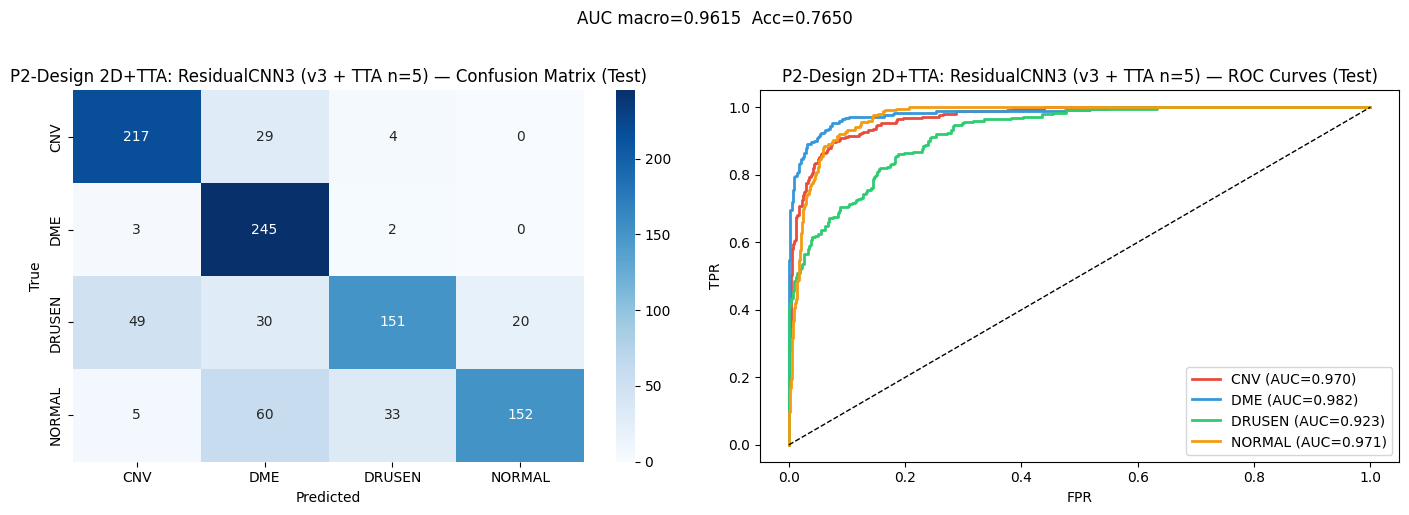

0.9615333333333334

In [19]:
# ── [ITEM 3] Test-Time Augmentation ──────────────────────────────────────

tta_aug = T.Compose([
    T.RandomHorizontalFlip(p=0.5),
    T.RandomRotation(degrees=5),
])

def tta_predict(model, images_uint8, n_aug=5):
    """Average predictions over n_aug augmented passes."""
    model.eval()
    # images_uint8: numpy (N, 28, 28)
    all_probs = []
    for _ in range(n_aug):
        batch_tensors = []
        for img in images_uint8:
            t = torch.tensor(img / 255.0, dtype=torch.float32).unsqueeze(0)  # (1,28,28)
            # apply tta augmentation as tensor operations
            if torch.rand(1) > 0.5:
                t = torch.flip(t, dims=[2])   # horizontal flip
            angle = (torch.rand(1).item() - 0.5) * 10.0  # ±5 deg
            import torchvision.transforms.functional as TF
            t = TF.rotate(t, angle)
            batch_tensors.append(t)
        batch = torch.stack(batch_tensors)   # (N,1,28,28)
        with torch.no_grad():
            logits = model(batch.to(device))
            probs  = F.softmax(logits, dim=1).cpu().numpy()
        all_probs.append(probs)
    return np.stack(all_probs).mean(axis=0)   # (N, 4)

print("Running TTA inference (n=5 augmented passes)...")
t0 = time.time()
yprob_2d_tta = tta_predict(cnn3_model, test_images, n_aug=5)
yp_2d_tta    = yprob_2d_tta.argmax(axis=1)
print(f"TTA inference complete in {time.time()-t0:.1f}s")

evaluate_model(y_test, yp_2d_tta, yprob_2d_tta, 'P2-Design 2D+TTA: ResidualCNN3 (v3 + TTA n=5)')


---
## [NEW v3] Explainable AI — Grad-CAM Heatmaps

Gradient-weighted class activation maps overlay the CNN3's attention onto original OCT B-scans,
showing exactly which retinal structures drive each diagnostic decision.


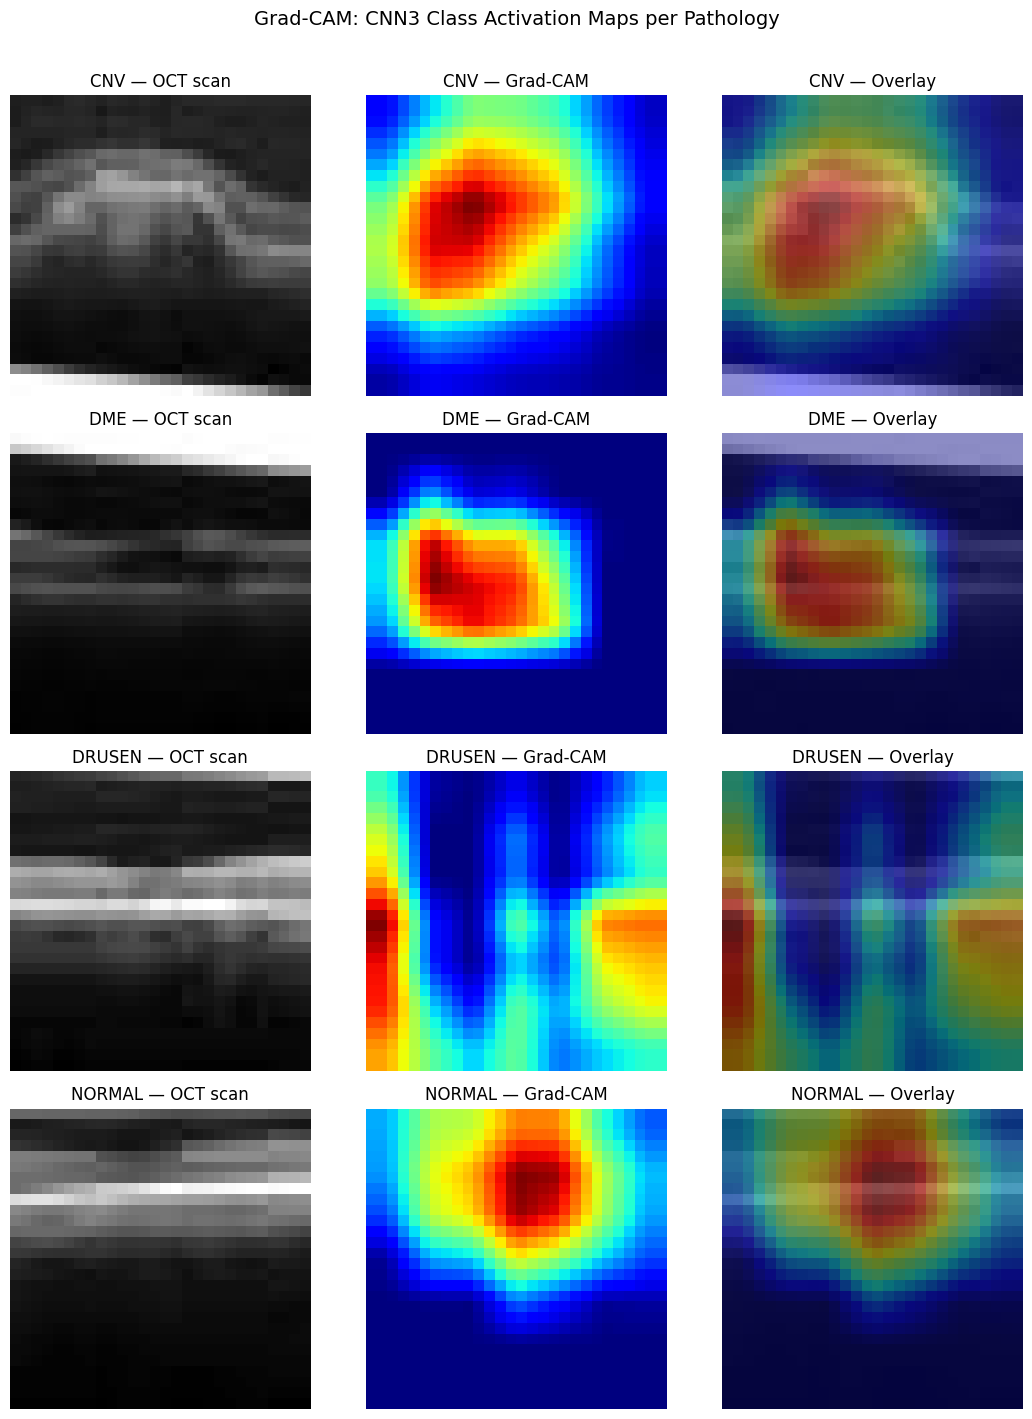

Grad-CAM visualization complete. Saved to gradcam_v3.png


In [20]:
# ── [ITEM 13] Grad-CAM Visualization ─────────────────────────────────────

class GradCAM:
    """Grad-CAM using forward/backward hooks on the target conv layer."""
    def __init__(self, model, target_layer):
        self.model = model
        self.activations = None
        self.gradients   = None
        target_layer.register_forward_hook(self._save_activations)
        target_layer.register_full_backward_hook(self._save_gradients)

    def _save_activations(self, module, input, output):
        self.activations = output.detach()

    def _save_gradients(self, module, grad_in, grad_out):
        self.gradients = grad_out[0].detach()

    def compute_cam(self, input_tensor, class_idx):
        self.model.eval()
        logits = self.model(input_tensor)
        self.model.zero_grad()
        score = logits[0, class_idx]
        score.backward()
        weights = self.gradients.mean(dim=[2, 3], keepdim=True)  # (1, C, 1, 1)
        cam = (weights * self.activations).sum(dim=1).squeeze(0)  # (H, W)
        cam = F.relu(cam)
        cam -= cam.min()
        if cam.max() > 0:
            cam /= cam.max()
        return cam.cpu().numpy()


# Build GradCAM on the last stage3 conv layer
gradcam = GradCAM(cnn3_model, cnn3_model.stage3.conv2)

# Pick one correctly-classified example per class
fig, axes = plt.subplots(4, 3, figsize=(11, 14))
fig.suptitle("Grad-CAM: CNN3 Class Activation Maps per Pathology", fontsize=14, y=1.01)

for cls in range(4):
    # Find a correctly classified test image of this class
    correct_idxs = np.where((y_test == cls) & (yp_2d == cls))[0]
    if len(correct_idxs) == 0:
        correct_idxs = np.where(y_test == cls)[0]
    idx = correct_idxs[0]
    img_np = test_images[idx]                                  # (28, 28) uint8

    inp = torch.tensor(img_np / 255.0, dtype=torch.float32).unsqueeze(0).unsqueeze(0).to(device)
    cam = gradcam.compute_cam(inp, class_idx=cls)

    # Upsample cam to 28×28
    cam_tensor = torch.tensor(cam).unsqueeze(0).unsqueeze(0)
    cam_up = F.interpolate(cam_tensor, size=(28, 28), mode='bilinear', align_corners=False)
    cam_up = cam_up.squeeze().numpy()

    # Plot: OCT | Heatmap | Overlay
    axes[cls, 0].imshow(img_np, cmap='gray')
    axes[cls, 0].set_title(f'{CLASS_NAMES[cls]} — OCT scan')
    axes[cls, 0].axis('off')

    axes[cls, 1].imshow(cam_up, cmap='jet')
    axes[cls, 1].set_title(f'{CLASS_NAMES[cls]} — Grad-CAM')
    axes[cls, 1].axis('off')

    # Normalize OCT to [0,1] for overlay
    img_norm = img_np.astype(np.float32) / 255.0
    heatmap_rgb = cm.jet(cam_up)[:, :, :3]
    overlay = 0.55 * np.stack([img_norm]*3, axis=-1) + 0.45 * heatmap_rgb
    overlay = np.clip(overlay, 0, 1)
    axes[cls, 2].imshow(overlay)
    axes[cls, 2].set_title(f'{CLASS_NAMES[cls]} — Overlay')
    axes[cls, 2].axis('off')

plt.tight_layout()
plt.savefig('gradcam_v3.png', dpi=150, bbox_inches='tight')
plt.show()
print("Grad-CAM visualization complete. Saved to gradcam_v3.png")


---
## [NEW v3] Explainable AI — SHAP Feature Importance

SHAP (SHapley Additive exPlanations) on the XGBoost model quantifies the contribution of each of the 66 custom retinal features to each diagnostic prediction.


Training Random Forest on 66 custom features for TreeExplainer SHAP analysis...


SHAP computation complete in 21.3s


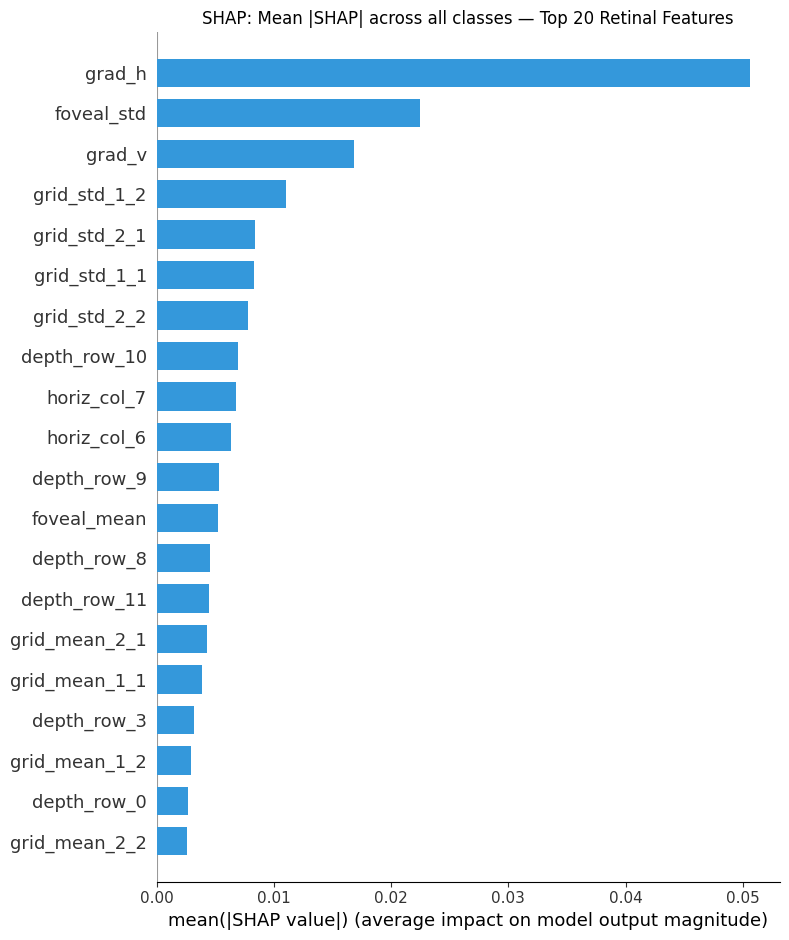

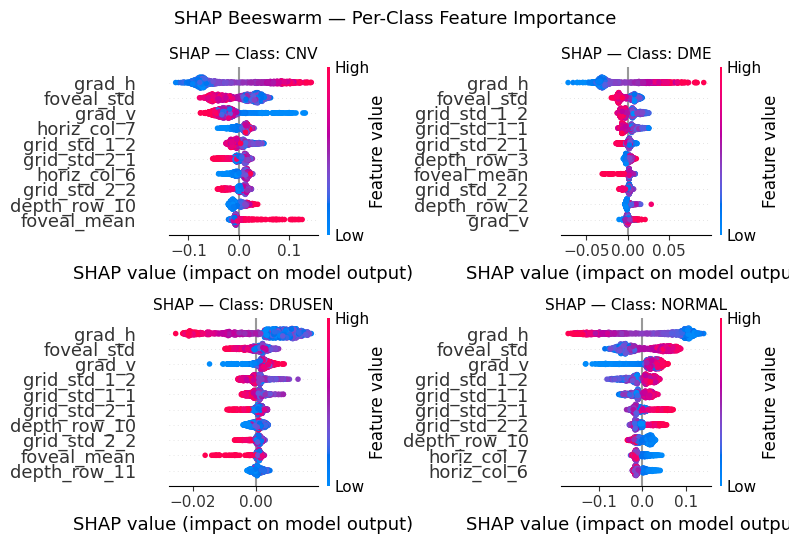

SHAP plots generated and saved successfully.


In [21]:
# ── [ITEM 14] SHAP Feature Importance ────────────────────────────────────

print("Training Random Forest on 66 custom features for TreeExplainer SHAP analysis...")
t0 = time.time()
rf_shap = RandomForestClassifier(n_estimators=100, max_depth=8, random_state=42, n_jobs=-1)
rf_shap.fit(X_train_feat, y_train)

explainer = shap.TreeExplainer(rf_shap)
shap_values = explainer.shap_values(X_test_feat)  # shape (N, 66, 4) or list of 4 (N, 66)
print(f"SHAP computation complete in {time.time()-t0:.1f}s")

# Convert to consistent per-class format
if isinstance(shap_values, list):
    shap_per_class = shap_values
    shap_abs_mean = np.mean([np.abs(sv) for sv in shap_values], axis=0)
elif isinstance(shap_values, np.ndarray) and shap_values.ndim == 3:
    shap_per_class = [shap_values[:, :, c] for c in range(shap_values.shape[2])]
    shap_abs_mean = np.mean(np.abs(shap_values), axis=2)
else:
    shap_per_class = [shap_values]
    shap_abs_mean = np.abs(shap_values)

# ── Global Bar Summary Plot ──
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_abs_mean, X_test_feat, feature_names=FEATURE_NAMES,
                  max_display=20, plot_type='bar', show=False, color='#3498db')
plt.title("SHAP: Mean |SHAP| across all classes — Top 20 Retinal Features", fontsize=12)
plt.tight_layout()
plt.savefig('shap_summary_bar.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Per-Class Beeswarm Plots ──
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
for cls_i, (ax, cls_name) in enumerate(zip(axes.flatten(), CLASS_NAMES)):
    plt.sca(ax)
    shap.summary_plot(shap_per_class[cls_i], X_test_feat, feature_names=FEATURE_NAMES,
                      max_display=10, show=False, plot_type='dot')
    ax.set_title(f'SHAP — Class: {cls_name}', fontsize=11)

plt.suptitle("SHAP Beeswarm — Per-Class Feature Importance", fontsize=13)
plt.tight_layout()
plt.savefig('shap_beeswarm_perclass.png', dpi=150, bbox_inches='tight')
plt.show()
print("SHAP plots generated and saved successfully.")


---
## Comprehensive Multi-Model Comparative Synthesis (v3)


In [22]:
# ── Full Comparison Table ─────────────────────────────────────────────────
df = pd.DataFrame(results_records)
df_test = df[df['Split'] == 'Test'].copy()
df_test = df_test.drop(columns=['Split']).reset_index(drop=True)

# Sort by ROC AUC descending
df_test = df_test.sort_values('ROC AUC (Macro OvR)', ascending=False).reset_index(drop=True)

fmt = {'Accuracy':'{:.4f}','Balanced Acc':'{:.4f}',
       'Precision (Macro)':'{:.4f}','Recall (Macro)':'{:.4f}',
       'F1 (Macro)':'{:.4f}','F1 (Weighted)':'{:.4f}',
       'ROC AUC (Macro OvR)':'{:.4f}'}
display(df_test.style.format(fmt).highlight_max(
    subset=['Accuracy','Balanced Acc','F1 (Macro)','ROC AUC (Macro OvR)'],
    color='#d4edda').set_caption("v3 Model Comparison — All Designs Ranked by Macro ROC AUC"))


,Model,Accuracy,Balanced Acc,Precision (Macro),Recall (Macro),F1 (Macro),F1 (Weighted),ROC AUC (Macro OvR)
0,P2-Design 2C: Deep Regularized CNN2 (v2),0.7590,0.7590,0.8221,0.7590,0.7389,0.7389,0.9696
1,P2-Design 2D+TTA: ResidualCNN3 (v3 + TTA n=5),0.7650,0.7650,0.7859,0.7650,0.7583,0.7583,0.9615
2,"P2-Design 2D: ResidualCNN3 (v3, no TTA)",0.7490,0.7490,0.7871,0.7490,0.7446,0.7446,0.9585
3,P2-Design 2B: Baseline CNN1,0.6650,0.6650,0.5305,0.6650,0.5756,0.5756,0.9374
4,P2-Design 2A: Deep MLP (66 Features),0.5870,0.5870,0.6659,0.5870,0.5087,0.5087,0.8924
5,P1-Design 1E: XGBoost GPU (66 Features),0.5900,0.5900,0.7488,0.5900,0.5115,0.5115,0.8834
6,P1-Design 1C: HGB 66-Features,0.5800,0.5800,0.6707,0.5800,0.5020,0.5020,0.8755
7,P1-Design 1A: Soft Voting Ensemble,0.4770,0.4770,0.5828,0.4770,0.3576,0.3576,0.8184
8,P1-Design 1D: Optimized HGB Full Pixels,0.4910,0.4910,0.5818,0.4910,0.3765,0.3765,0.8159
9,P1-Design 1B: PCA + Stacking,0.4520,0.4520,0.4244,0.4520,0.3595,0.3595,0.7932


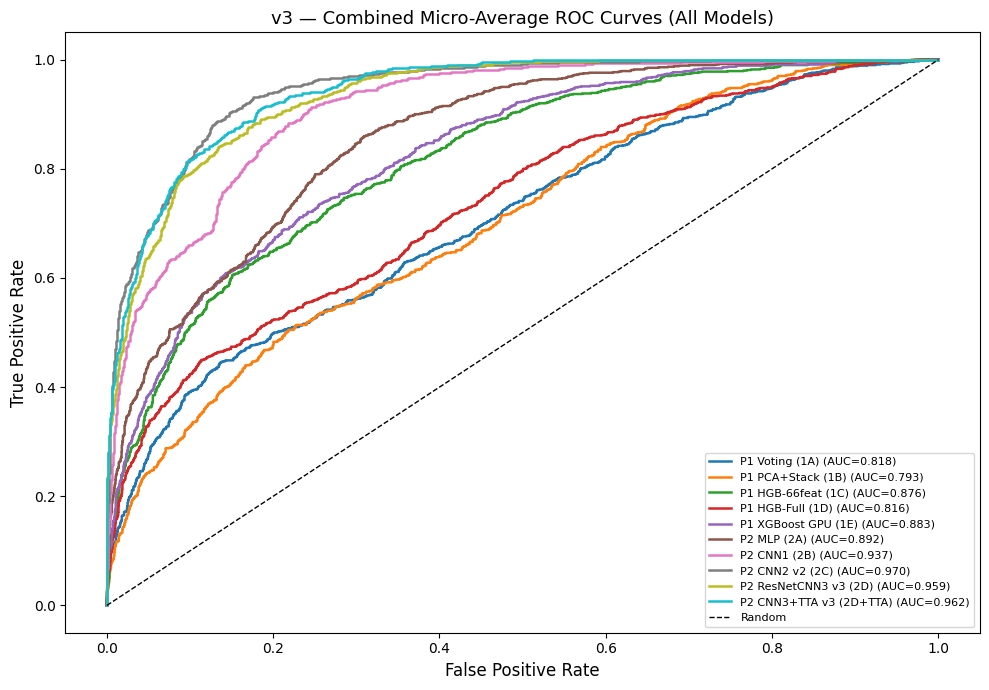

In [23]:
# ── Combined ROC Curves — All Models ─────────────────────────────────────
plt.figure(figsize=(10, 7))

model_probs = [
    ("P1 Voting (1A)",          y_test, y_prob_1a),
    ("P1 PCA+Stack (1B)",       y_test, y_prob_1b),
    ("P1 HGB-66feat (1C)",      y_test, y_prob_1c),
    ("P1 HGB-Full (1D)",        y_test, y_prob_1d),
    ("P1 XGBoost GPU (1E)",     y_test, y_prob_1e),
    ("P2 MLP (2A)",             yl_2a,  yprob_2a),
    ("P2 CNN1 (2B)",            yl_2b,  yprob_2b),
    ("P2 CNN2 v2 (2C)",         yl_2c,  yprob_2c),
    ("P2 ResNetCNN3 v3 (2D)",   yl_2d,  yprob_2d),
    ("P2 CNN3+TTA v3 (2D+TTA)", y_test, yprob_2d_tta),
]
colors = plt.cm.tab10(np.linspace(0, 1, len(model_probs)))

y_bin_all = label_binarize(y_test, classes=[0,1,2,3])
for (name, yt, yp), col in zip(model_probs, colors):
    y_b = label_binarize(yt, classes=[0,1,2,3])
    try:
        macro_auc = roc_auc_score(y_b, yp, multi_class='ovr', average='macro')
        # Micro average for ROC curve
        fpr, tpr, _ = roc_curve(y_b.ravel(), yp.ravel())
        plt.plot(fpr, tpr, color=col, lw=1.8, label=f"{name} (AUC={macro_auc:.3f})")
    except:
        pass

plt.plot([0,1],[0,1],'k--',lw=1,label='Random')
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('v3 — Combined Micro-Average ROC Curves (All Models)', fontsize=13)
plt.legend(loc='lower right', fontsize=8)
plt.tight_layout()
plt.savefig('roc_combined_v3.png', dpi=150, bbox_inches='tight')
plt.show()
